案例说明：本案例属于自然语言处理领域的文本分类问题，使用的IMDB数据集是一个常用的二分类电影评论数据集，包含文本和标签两个部分，包括50,000条电影评论，本项目中40,000条用于训练，10,000条用于测试。通过搭建循环神经网络，完成文本情感分析项目开发。
### 注意：已有代码请勿修改，在***处编写代码，并将指定区域的代码及结果上传至竞赛平台上。


In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

1：使用Pandas从datasets文件夹中读取名为 'IMDB Dataset.csv' 的文件，返回变量init_data。  

In [ ]:
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######
init_data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


2：绘制词云图。请编程获取第5个样本的词云图，赋值给变量cloud_negative。  

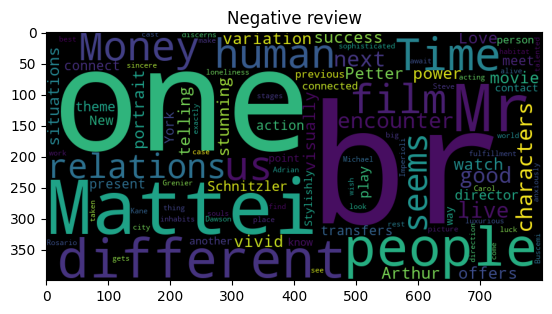

In [ ]:
from wordcloud import WordCloud
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######
plt.imshow(cloud_negative)
plt.title('Negative review')
plt.show()

In [6]:
import re
def remove_url(text):
    url_tag = re.compile(r'https://\S+|www\.\S+')
    text = url_tag.sub(r'', text)
    return text
def remove_html(text):
    html_tag = re.compile(r'<.*?>')
    text = html_tag.sub(r'', text)
    return text
def remove_punctuation(text): 
    punct_tag = re.compile(r'[^\w\s]')
    text = punct_tag.sub(r'', text) 
    return text   
def remove_special_character(text):
    special_tag = re.compile(r'[^a-zA-Z0-9\s]')
    text = special_tag.sub(r'', text)
    return text
def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # 表情符号
                               u"\U0001F300-\U0001F5FF"  # 符号和象形文字
                               u"\U0001F680-\U0001F6FF"  # 交通和地图符号
                               u"\U0001F1E0-\U0001F1FF"  # 标志（iOS）
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    return text 

3：定义一个名为clean_text的函数，要求函数功能：依次执行remove_url()、remove_html()、remove_punctuation()、remove_special_character()、remove_emojis()一系列清洗操作，并将所有文字转小写。  

In [ ]:
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######

4：使用clean_text函数，对init_data中的 'review' 列进行文本清洗处理，并将结果存储到新列 'processed' 中。    

In [ ]:
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######
init_data.head()

,review,sentiment,processed,label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,1


In [13]:
init_data['label'] = init_data['sentiment'].apply(lambda x:1 if x=='positive' else 0 )

In [11]:
from sklearn.model_selection import train_test_split
x=init_data['processed']
y=init_data['label']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

5：创建一个分词器token，限制词汇表大小为 5000 个最常用单词。  

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######

token.fit_on_texts(x_train)
token.word_index

{'the': 1,
 'a': 2,
 'and': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'in': 7,
 'it': 8,
 'i': 9,
 'this': 10,
 'that': 11,
 'was': 12,
 'as': 13,
 'for': 14,
 'with': 15,
 'movie': 16,
 'but': 17,
 'film': 18,
 'on': 19,
 'not': 20,
 'you': 21,
 'are': 22,
 'his': 23,
 'have': 24,
 'be': 25,
 'he': 26,
 'one': 27,
 'its': 28,
 'at': 29,
 'all': 30,
 'by': 31,
 'an': 32,
 'they': 33,
 'who': 34,
 'from': 35,
 'like': 36,
 'so': 37,
 'or': 38,
 'just': 39,
 'her': 40,
 'about': 41,
 'has': 42,
 'out': 43,
 'if': 44,
 'some': 45,
 'there': 46,
 'what': 47,
 'good': 48,
 'when': 49,
 'more': 50,
 'very': 51,
 'even': 52,
 'up': 53,
 'no': 54,
 'my': 55,
 'would': 56,
 'she': 57,
 'time': 58,
 'only': 59,
 'which': 60,
 'really': 61,
 'their': 62,
 'see': 63,
 'were': 64,
 'had': 65,
 'can': 66,
 'story': 67,
 'me': 68,
 'than': 69,
 'much': 70,
 'we': 71,
 'well': 72,
 'been': 73,
 'get': 74,
 'will': 75,
 'into': 76,
 'great': 77,
 'other': 78,
 'bad': 79,
 'do': 80,
 'also': 81,
 'because': 82,

6：使用token对象的相关方法，将原始文本数据x_train和x_test转换为数值序列，分别赋值给变量x_train_seq和x_test_seq。  
注意：本题需同时上传代码和运行结果。  

In [ ]:
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######
print(x_train_seq[0])

[9, 223, 32, 190, 18, 4228, 3, 24, 2155, 55, 1192, 1463, 4, 1211, 1253, 37, 9, 24, 2, 5, 1661, 10, 18, 31, 8, 725, 3532, 7, 1, 3900, 4, 1, 241, 190, 93, 1, 2430, 42, 5, 1426, 8, 202, 13, 683, 13, 315, 4, 1, 2489, 8, 202, 13, 2068, 13, 3, 1435, 1, 1183, 1078, 4, 220, 158, 43, 46, 11, 106, 291, 10, 18, 42, 54, 1078, 373, 7, 341, 1, 16, 6, 14, 2, 317, 267, 18, 1, 621, 19, 1, 141, 4, 1, 263, 932, 685, 573, 35, 10, 46, 6, 947, 4, 583, 17, 1908, 104, 8, 30, 152, 2, 2701, 1108, 1378, 3, 1, 2589, 1624, 31, 3, 30, 1, 78, 1376, 4821, 4, 596, 11, 190, 93, 627, 67, 1, 67, 2628, 19, 34, 1146, 40, 388, 5, 100, 10, 18, 12, 89, 34, 2, 289, 4283, 29, 2, 3716, 83, 363, 5, 776, 3, 2112, 1, 492, 6, 40, 6, 8, 40, 164, 15, 2, 502, 38, 1, 1385, 5, 25, 1152, 8, 6, 1195, 5, 446, 82, 1, 227, 146, 2366, 43, 96, 107, 971, 377, 19, 30, 2069, 10, 1211, 42, 1, 225, 4, 2, 375, 355, 321, 375, 11, 6, 82, 1092, 1378, 95, 94, 2, 122, 490, 69, 10, 2, 4, 628, 13, 120, 13, 27, 4, 1, 1378, 17, 299, 327, 6, 4, 1, 2258, 4, 110

In [16]:
for item in x_train_seq[:10]:
    print(len(item))

233
105
68
67
243
130
275
117
255
176


7：使用pad_sequences函数对整数序列数据x_train_seq和x_test_seq填充或截断到相同的长度（maxlen=100），分别返回变量x_train和x_test。  
Задание 90: Используйте функцию pad_sequences для дополнения или обрезания целочисленных последовательностей x_train_seq и x_test_seq до одинаковой длины (maxlen=100), затем сохраните результаты в переменные x_train и x_test.

In [ ]:
from tensorflow.keras.preprocessing import sequence
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######

In [18]:
for item in x_train[:10]:
    print(len(item))

100
100
100
100
100
100
100
100
100
100


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense,Dropout,Flatten

8：使用keras顺序式接口，搭建循环神经网络，  
第一层为Embedding层，词汇表大小5000，词嵌入维度为32，输入序列的固定长度为100；  
第二层为LSTM，输出维度为16；  
第三层为Dropout层，抑制过拟合，参数自行设置；  
第四层为Dense层，输出节点数根据本任务决定，激活函数须与损失函数匹配。  

In [ ]:
######上传此部分代码(Upload the Code)######
***
######上传此部分代码(Upload the Code)######

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer='adam',
              metrics=['accuracy'])

In [23]:
train_history=model.fit(x_train,y_train,batch_size=256,
                        epochs=10,verbose=1,
                        validation_split=0.2)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6381 - loss: 0.6447 - val_accuracy: 0.8367 - val_loss: 0.3877
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6381 - loss: 0.6447 - val_accuracy: 0.8367 - val_loss: 0.3877
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8595 - loss: 0.3606 - val_accuracy: 0.8540 - val_loss: 0.3416
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8865 - loss: 0.2993 - val_accuracy: 0.8424 - val_loss: 0.3609
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8976 - loss: 0.2730 - val_accuracy: 0.8525 - val_loss: 0.3477
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9104 - loss: 0.2431 - val_accuracy: 0.8471 - val_loss: 0.3807
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9187 - loss: 0.2242 - val_accuracy: 0.8512 - val_loss: 0.3706
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9281 - loss: 0.2025 - val_accu

In [24]:
scores=model.evaluate(x_test,y_test,verbose=1)
scores

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8463 - loss: 0.4350
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8463 - loss: 0.4350


[0.42814671993255615, 0.8458999991416931]